<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 08</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Evaluation</div><div style="font-size:1.05em;opacity:0.85">Rank well, and stay calibrated when the season turns.</div></div>

Stage 07 trained three supervised models but could not test the question that sank the
baselines: do the probabilities stay right when the season changes? This stage calibrates every
model on the June 2011 cutoff and judges all five rungs of the ladder on the September 2011 test
cutoff, with confidence intervals. It then follows every model across the four later cutoffs
nobody fitted on, and checks which inputs drift.

**Pipeline rule.** `churnvalue evaluate` writes `reports/evaluation.json` — metrics with
customer-clustered bootstrap CIs, curves, the per-cutoff stability table and feature drift —
and this notebook only reads it. The same file ships to the web app.

| | |
|---|---|
| **Input** | `reports/evaluation.json` |
| **Outputs** | `reports/results/08_summary.json` · `reports/figures/08_*.png` |
| **Parameters** | `configs/default.yaml` → `evaluation` (1,000 bootstrap resamples, seed 42, γ ~ Beta(6, 14) for EMP) |
| **Shared code** | `churnvalue.evaluate` · `churnvalue.metrics` · `churnvalue.curves` · `churnvalue.monitoring` · `churnvalue.calibration` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">V1 test metrics</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">V2 curves</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">V3 reliability</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">V4 stability</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">V5 drift</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from churnvalue.config import load_config, project_root
from churnvalue.monitoring import PSI_BANDS
from churnvalue.reporting import StageSummary
from churnvalue.viz import style
from churnvalue.viz.style import INK, MODEL_COLORS, MODEL_LABELS, MUTED, SEQUENTIAL

os.chdir(project_root())
CFG = load_config()
STAGE, FIGURES, RESULTS = "08", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


report = json.loads((CFG.reports_dir / "evaluation.json").read_text(encoding="utf-8"))
models = report["models"]
ORDER = list(models)
test_rate = report["test_population"]["churn_rate"]
n_test = report["test_population"]["n_customers"]
S["test_cutoff"] = report["split"]["test"]
S["test_churn_rate"] = test_rate
S["calibration_churn_rate"] = report["calibration_population"]["churn_rate"]

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">V1 · Test metrics</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the supervised rungs rank better; one is also calibrated</span></div>

Ranking (PR-AUC, ROC-AUC) improves clearly from the baselines to the supervised models, and the
three supervised models are close to each other — their intervals overlap. The **Brier score**,
which also punishes probabilities at the wrong level, separates them: LightGBM + season has the
lowest. EMP, the expected maximum profit per customer over plausible acceptance rates, is a
ranking-based money metric and does not see calibration either — which is why stage 10 still
has to look at the realized profit of the policy the probabilities choose.

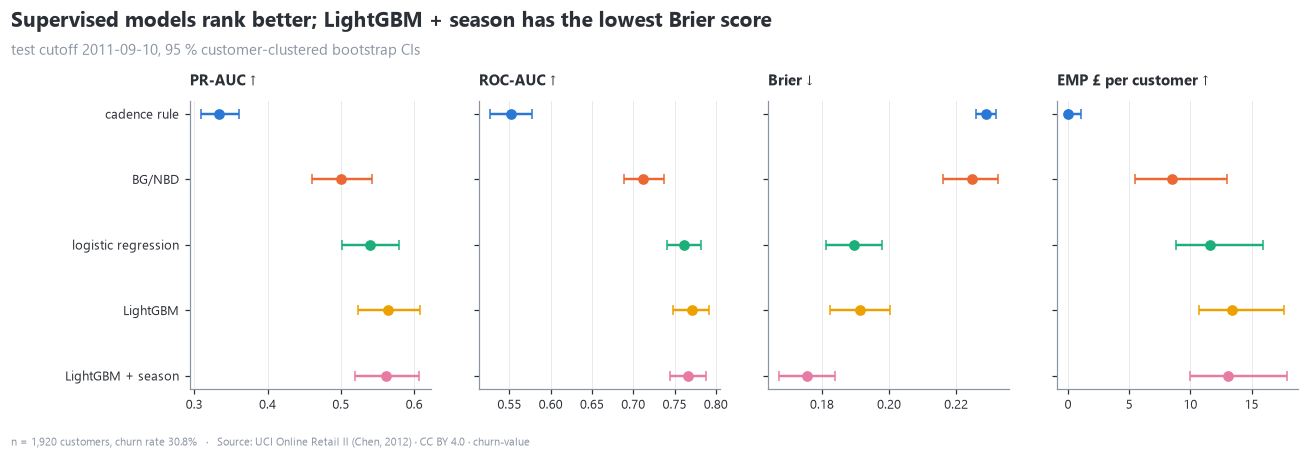

In [2]:
labels = {"pr_auc": "PR-AUC ↑", "roc_auc": "ROC-AUC ↑", "brier": "Brier ↓"}
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
y = np.arange(len(ORDER))[::-1]
for ax, key in zip(axes, [*labels, "emp"], strict=True):
    for yi, name in zip(y, ORDER, strict=True):
        e = models[name]["emp_per_customer"] if key == "emp" else models[name]["metrics"][key]
        ax.errorbar(
            e["value"],
            yi,
            xerr=[[e["value"] - e["ci_low"]], [e["ci_high"] - e["value"]]],
            fmt="o",
            color=MODEL_COLORS[name],
            capsize=3,
            markersize=6,
            lw=1.6,
        )
    ax.set_title(labels.get(key, "EMP £ per customer ↑"), fontsize=9.5)
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(y, [MODEL_LABELS[n] for n in ORDER])
S["metrics"] = {n: {k: v["value"] for k, v in models[n]["metrics"].items()} for n in ORDER}
S["emp"] = {n: models[n]["emp_per_customer"]["value"] for n in ORDER}
best_brier = min(ORDER, key=lambda n: models[n]["metrics"]["brier"]["value"])
S["best_brier_model"] = best_brier
style.headline(
    fig,
    "Supervised models rank better; LightGBM + season has the lowest Brier score",
    f"test cutoff {S['test_cutoff']}, 95 % customer-clustered bootstrap CIs",
)
style.add_source(fig, f"n = {n_test:,} customers, churn rate {test_rate:.1%}")
save(fig, "metrics")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">V2 · Curves</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">where in the ranking the models differ</span></div>

The precision–recall and ROC curves confirm the ordering above: the three supervised models
sit together, above BG/NBD, with the cadence rule close to random. The gains curve reads in
campaign terms: contacting the top 30 % of customers by predicted risk reaches about half of
the churners with the supervised models.

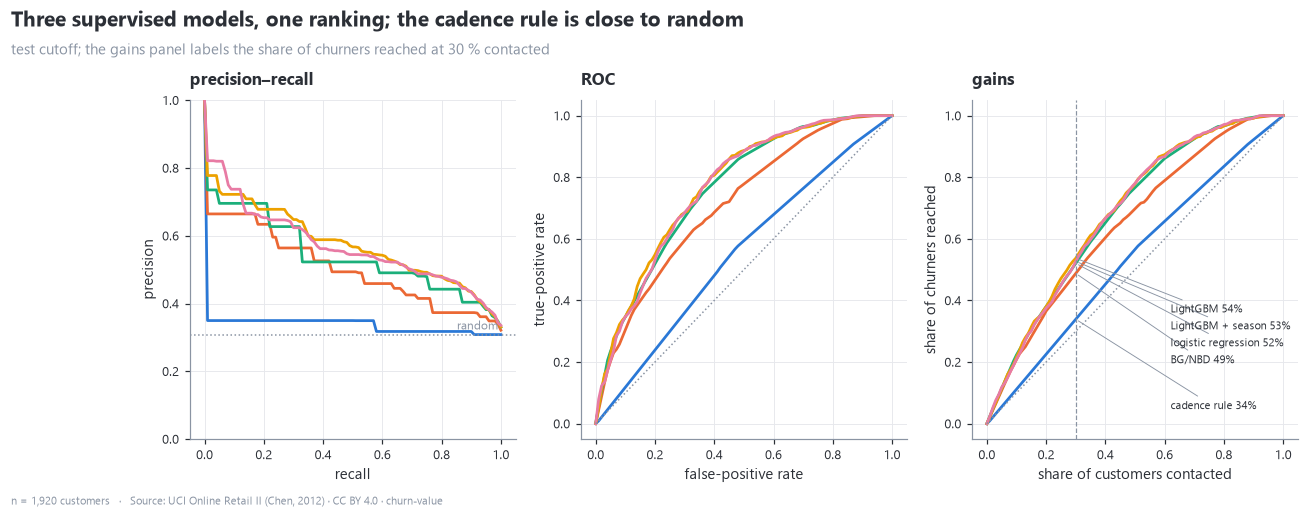

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for name in ORDER:
    curves = models[name]["curves"]
    axes[0].plot(
        curves["pr"]["recall"], curves["pr"]["precision"], color=MODEL_COLORS[name], lw=1.8
    )
    axes[1].plot(curves["roc"]["fpr"], curves["roc"]["tpr"], color=MODEL_COLORS[name], lw=1.8)
    axes[2].plot(
        curves["gains"]["fraction"], curves["gains"]["captured"], color=MODEL_COLORS[name], lw=1.8
    )
axes[0].axhline(test_rate, color=MUTED, lw=1, ls=":")
axes[0].text(0.99, test_rate + 0.015, "random", ha="right", fontsize=8, color=MUTED)
for ax in axes[1:]:
    ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls=":")
axes[0].set(title="precision–recall", xlabel="recall", ylabel="precision", ylim=(0, 1))
axes[1].set(title="ROC", xlabel="false-positive rate", ylabel="true-positive rate")
axes[2].set(
    title="gains", xlabel="share of customers contacted", ylabel="share of churners reached"
)
axes[0].title.set_fontsize(9.5)
axes[1].title.set_fontsize(9.5)
axes[2].title.set_fontsize(9.5)
at_30 = {
    n: float(
        np.interp(
            0.3, models[n]["curves"]["gains"]["fraction"], models[n]["curves"]["gains"]["captured"]
        )
    )
    for n in ORDER
}
S["gains_at_30pct"] = at_30
for name, yv in style.spread_positions(at_30, 0.055).items():
    axes[2].annotate(
        f"{MODEL_LABELS[name]} {at_30[name]:.0%}",
        (0.3, at_30[name]),
        xytext=(0.62, yv - 0.25),
        fontsize=7.5,
        color=INK,
        arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.6},
    )
axes[2].axvline(0.3, color=MUTED, lw=0.8, ls="--")
style.headline(
    fig,
    "Three supervised models, one ranking; the cadence rule is close to random",
    "test cutoff; the gains panel labels the share of churners reached at 30 % contacted",
)
style.add_source(fig, f"n = {n_test:,} customers")
save(fig, "curves")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">V3 · Reliability</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the season features are what keep September calibrated</span></div>

A reliability diagram bins customers by predicted probability and compares the bin's mean
prediction with the share who actually churned; a calibrated model sits on the diagonal. All
models were calibrated on June 2011, when 43 % churned; in September 31 % did. **BG/NBD and the
plain LightGBM keep June's level** and over-predict in almost every bin. LightGBM + season uses
the cutoff month and follows the diagonal.

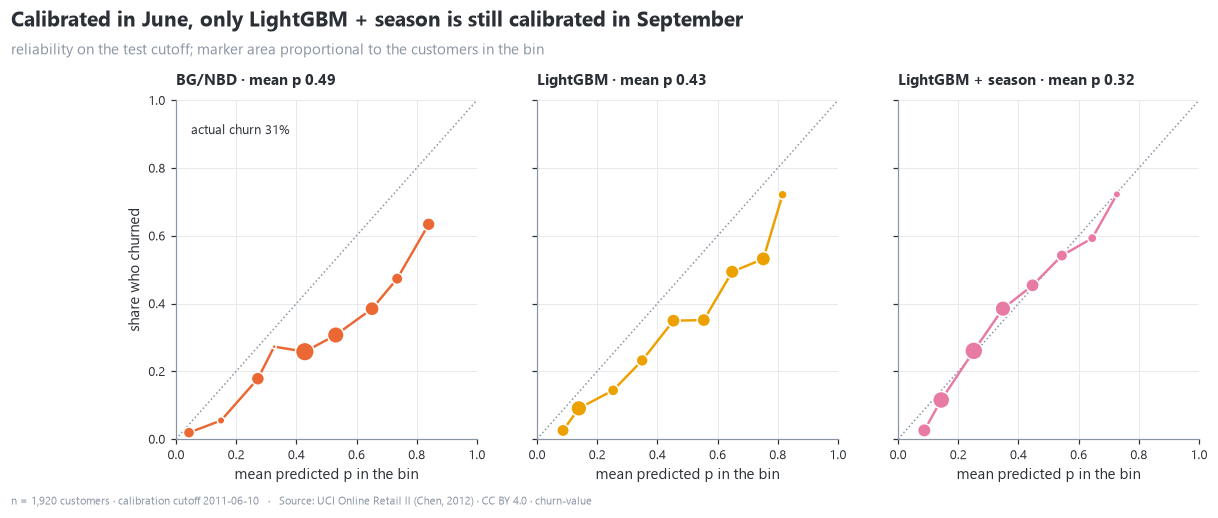

In [4]:
show = ["bgnbd", "lightgbm", "lightgbm_seasonal"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, name in zip(axes, show, strict=True):
    bins = pd.DataFrame(models[name]["curves"]["reliability"])
    ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls=":")
    ax.plot(bins["mean_p"], bins["churn_rate"], color=MODEL_COLORS[name], lw=1.6)
    ax.scatter(
        bins["mean_p"],
        bins["churn_rate"],
        s=bins["n"] / 3,
        color=MODEL_COLORS[name],
        edgecolor="white",
        linewidth=1,
        zorder=3,
    )
    ax.set_title(f"{MODEL_LABELS[name]} · mean p {models[name]['mean_p']:.2f}", fontsize=9.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("mean predicted p in the bin")
axes[0].set_ylabel("share who churned")
axes[0].text(0.05, 0.9, f"actual churn {test_rate:.0%}", fontsize=8.5, color=INK)
S["mean_p"] = {n: models[n]["mean_p"] for n in ORDER}
style.headline(
    fig,
    "Calibrated in June, only LightGBM + season is still calibrated in September",
    "reliability on the test cutoff; marker area proportional to the customers in the bin",
)
style.add_source(
    fig, f"n = {n_test:,} customers · calibration cutoff {report['split']['calibration']}"
)
save(fig, "reliability")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">V4 · Stability</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">four cutoffs nobody fitted on, plus calibration and test</span></div>

The same calibrated models, applied to every cutoff after the training window: April and May
2011 (between training and calibration), June (the calibration cutoff, calibrated by
construction), July and August (between calibration and test) and September (test). Ranking is
stable for every model. The **calibration gap** — mean predicted churn minus actual churn —
is not: for the models without the month it grows as the calendar moves away from June and
the churn rate falls, reaching +0.13 (LightGBM) and +0.18 (BG/NBD) in September. LightGBM +
season stays within ±0.035 on every cutoff.

The logistic regression sees the month too, and its gap still reaches +0.11 in September. A
likely reason: a single additive sine–cosine term, shrunk by the strong penalty of stage 07,
cannot reproduce the month-by-month level that the trees learn. Knowing the month is
necessary, not sufficient.

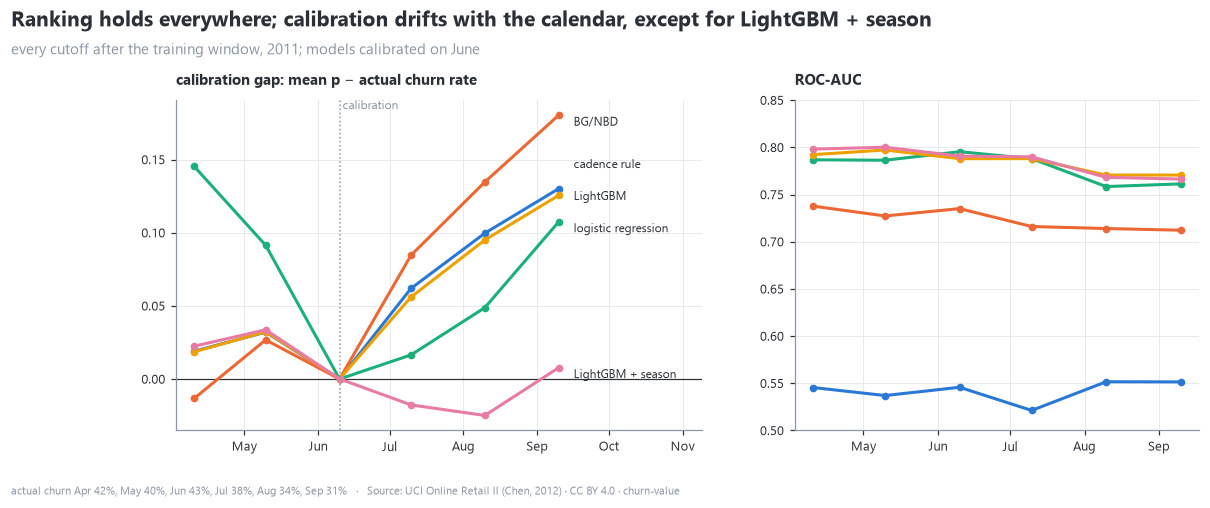

model,cadence rule,BG/NBD,logistic regression,LightGBM,LightGBM + season
cutoff,,,,,
2011-04-10 00:00:00,+0.019,-0.013,+0.145,+0.019,+0.022
2011-05-10 00:00:00,+0.032,+0.027,+0.091,+0.032,+0.034
2011-06-10 00:00:00,-0.000,+0.000,+0.000,+0.000,+0.000
2011-07-10 00:00:00,+0.062,+0.085,+0.016,+0.056,-0.018
2011-08-10 00:00:00,+0.100,+0.135,+0.049,+0.095,-0.025
2011-09-10 00:00:00,+0.130,+0.180,+0.107,+0.126,+0.008


In [5]:
stab = pd.DataFrame(report["stability"])
stab["cutoff"] = pd.to_datetime(stab["cutoff"])
stab["gap"] = stab["mean_p"] - stab["churn_rate"]
S["mean_abs_gap"] = stab.groupby("model")["gap"].apply(lambda g: g.abs().mean()).to_dict()
S["gap_at_test"] = stab[stab["role"] == "test"].set_index("model")["gap"].to_dict()
S["seasonal_gap_range"] = [
    stab.loc[stab["model"] == "lightgbm_seasonal", "gap"].min(),
    stab.loc[stab["model"] == "lightgbm_seasonal", "gap"].max(),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
ax.axhline(0, color=INK, lw=0.8)
last = stab["cutoff"].max()
for name in ORDER:
    part = stab[stab["model"] == name]
    ax.plot(part["cutoff"], part["gap"], "o-", color=MODEL_COLORS[name], markersize=4)
style.direct_labels(
    ax,
    last + pd.Timedelta(days=5),
    stab[stab["cutoff"] == last].set_index("model")["gap"].to_dict(),
    MODEL_LABELS,
    0.022,
)
cal_cutoff = pd.Timestamp(report["split"]["calibration"])
ax.axvline(cal_cutoff, color=MUTED, lw=1, ls=":")
ax.text(cal_cutoff, ax.get_ylim()[1], " calibration", fontsize=8, color=MUTED, va="top")
ax.set_xlim(None, last + pd.Timedelta(days=60))
ax.set_title("calibration gap: mean p − actual churn rate", fontsize=9.5)
ax.xaxis.set_major_formatter(lambda v, _: pd.Timestamp(np.datetime64(int(v), "D")).strftime("%b"))
ax = axes[1]
for name in ORDER:
    part = stab[stab["model"] == name]
    ax.plot(part["cutoff"], part["roc_auc"], "o-", color=MODEL_COLORS[name], markersize=4)
ax.set_title("ROC-AUC", fontsize=9.5)
ax.set_ylim(0.5, 0.85)
ax.xaxis.set_major_formatter(lambda v, _: pd.Timestamp(np.datetime64(int(v), "D")).strftime("%b"))
rates = stab.drop_duplicates("cutoff").set_index("cutoff")["churn_rate"]
style.headline(
    fig,
    "Ranking holds everywhere; calibration drifts with the calendar, except for LightGBM + season",
    "every cutoff after the training window, 2011; models calibrated on June",
)
style.add_source(fig, "actual churn " + ", ".join(f"{d:%b} {r:.0%}" for d, r in rates.items()))
save(fig, "stability")
plt.show()
display(
    stab.pivot(index="cutoff", columns="model", values="gap")[ORDER]
    .rename(columns=MODEL_LABELS)
    .style.format("{:+.3f}")
)

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">V5 · Drift</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">structural in two features, calendar-driven in a few</span></div>

The population stability index (PSI) compares each feature's distribution at a cutoff with the
pooled training cutoffs; above 0.25 is conventionally a major shift. Three kinds of movement
show up:

- **Structural**, because the data begin in December 2009. `tenure_days` can only grow as the
  data age. `bought_same_window_last_year` is **censored** at the first training cutoffs: from
  June to August 2010 the "same window last year" lies before the first transaction, so the
  feature is 0 for everyone, and from September to November 2010 it is only partly observed.
- **Calendar**, at single cutoffs. The shop sold nothing from 23 December 2010 to 4 January
  2011, so at the January cutoff every customer's last purchase looks older: median recency jumps
  from 25 to 47 days. In March the 90-day spend windows compare a quiet winter with the Q4 peak,
  so `spend_trend` collapses.
- **None**: order value, return rate and country never move.

Stage 11 measures what the censored feature is worth.

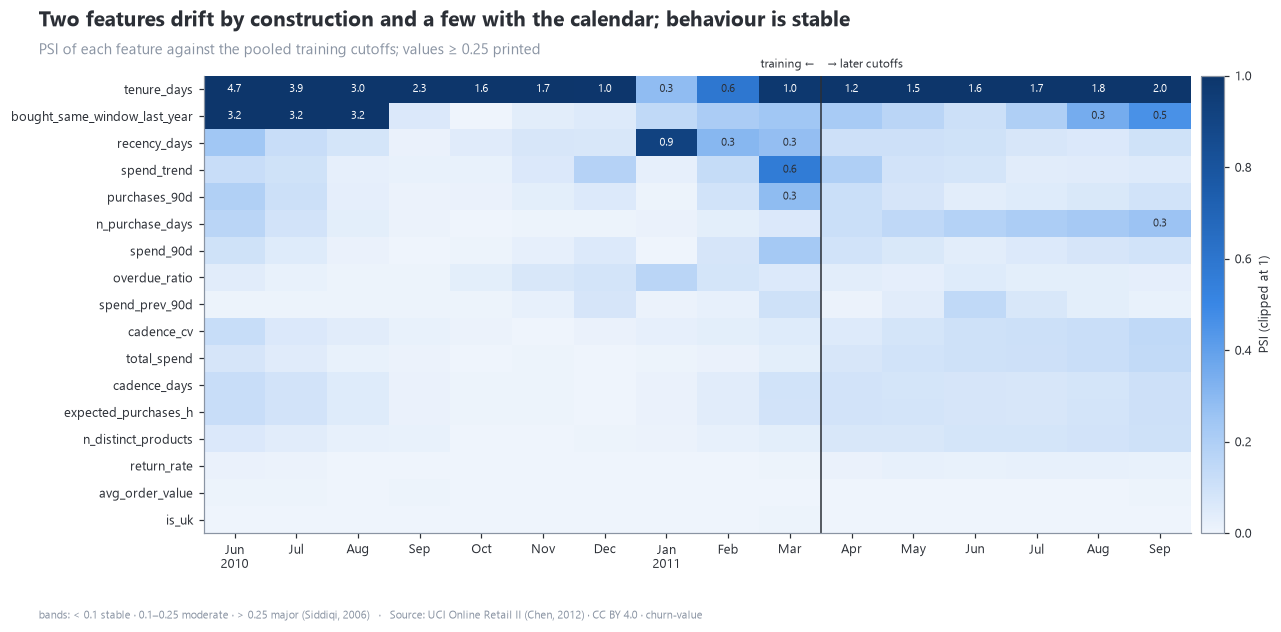

In [6]:
drift = pd.DataFrame(report["drift"])
drift["cutoff"] = pd.to_datetime(drift["cutoff"])
table = drift.pivot(index="feature", columns="cutoff", values="psi")
table = table.loc[table.max(axis=1).sort_values(ascending=False).index]
S["psi_max_by_feature"] = table.max(axis=1).to_dict()
S["n_features_major_shift_at_test"] = int((table.iloc[:, -1] > 0.25).sum())
tx = pd.read_parquet(CFG.data.interim_dir / "transactions.parquet")
days = pd.Series(np.sort(tx["date"].unique()))
days = days[(days > "2010-12-01") & (days <= "2011-01-10")].reset_index(drop=True)
gap = days.diff().idxmax()
S["christmas_closure_2010"] = [days[gap - 1], days[gap]]
snapshots = pd.read_parquet(CFG.data.interim_dir / "snapshots.parquet")
median_recency = snapshots.groupby("cutoff")["recency_days"].median()
S["median_recency_dec_jan"] = [
    median_recency[pd.Timestamp("2010-12-10")],
    median_recency[pd.Timestamp("2011-01-10")],
]
fig, ax = plt.subplots(figsize=(12, 5.4))
clipped = table.clip(upper=1.0)
image = ax.imshow(clipped.to_numpy(), cmap=SEQUENTIAL, aspect="auto", vmin=0, vmax=1.0)
ax.set_yticks(range(len(table)), table.index)
ax.set_xticks(
    range(table.shape[1]),
    [
        f"{c:%b}\n{c:%Y}" if c.month == 1 or i == 0 else f"{c:%b}"
        for i, c in enumerate(table.columns)
    ],
)
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        value = table.iat[i, j]
        if value >= 0.25:
            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if value > 0.6 else INK,
            )
ax.grid(False)
n_train = len(report["split"]["train"])
ax.axvline(n_train - 0.5, color=INK, lw=1)
ax.text(n_train - 0.6, -0.8, "training ←", ha="right", fontsize=8, color=INK)
ax.text(n_train - 0.4, -0.8, "→ later cutoffs", ha="left", fontsize=8, color=INK)
colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.01)
colorbar.set_label("PSI (clipped at 1)", fontsize=8.5)
style.headline(
    fig,
    "Two features drift by construction and a few with the calendar; behaviour is stable",
    f"PSI of each feature against the pooled training cutoffs; values ≥ {PSI_BANDS[1][0]} printed",
)
style.add_source(fig, "bands: < 0.1 stable · 0.1–0.25 moderate · > 0.25 major (Siddiqi, 2006)")
save(fig, "drift")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">08 → 09, 10, 11</span></div>

**Produced** — `reports/results/08_summary.json` and the figures `08_metrics`, `08_curves`,
`08_reliability`, `08_stability`, `08_drift`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>The three supervised models rank alike and clearly better than the baselines. Only LightGBM + season is also calibrated in September: its calibration gap stays within a few points on every later cutoff, where the plain LightGBM and BG/NBD drift to +0.13 and +0.18, and the logistic regression, which also sees the month, to +0.11.</li><li>Feature drift is structural or calendar-driven, not behavioural: tenure grows with the data, the "same window last year" flag is censored at the first training cutoffs, and the Christmas closure and the Q4 peak move recency and the spend trend at single cutoffs.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>The deployed model stays LightGBM + season, as fixed before this evaluation; its calibration on the later cutoffs is what makes its expected profit trustworthy.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>09_explainability</b> — what the tree model looks at, per customer.</li><li><b>10_business_value</b> — the realized profit of every policy, and how it moves with the assumptions.</li><li><b>11_ablation</b> — the censored feature, the month features and the calibration fixes that do not work.</li></ul></div>

In [7]:
S.write(RESULTS)

WindowsPath('reports/results/08_summary.json')